## Setup

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [29]:
class SimpleNet:

    # Initialise network parameters
    def __init__(self, N):
        self.W = [1] * N
        self.B = [0] * N
        self.A = [1] * N
        self.N = N

    # Forward pass on single value
    # Added optional n to only sum first n neurons
    def forward(self, x, n = None):
        
        # Load network parameters
        W, B, A, N = self.W, self.B, self.A, self.N

        # Optionally set N to n
        if n is not None:
            N = n

        # Calculate & sum ReLUs
        y = 0
        for i in range(N):
            y += A[i] * max(0, W[i] * x + B[i])
            
        return y
    
    # Update network parameters
    def update_weights(self, W = None, B = None, A = None):
        if W is not None:
            self.W = W
        if B is not None:
            self.B = B
        if A is not None:
            self.A = A

    # Plot network for specified range
    # Added optional n to only plot first n neurons
    def plot(self, start = -10, stop = 10, n = None, res = 10):

        # Calculate values for range
        x = np.linspace(start, stop, abs(start) * res + abs(stop) * res + 1)
        y = [self.forward(point, n) for point in x]

        # Load network parameters
        W, B, A, N = self.W, self.B, self.A, self.N

        # Create title string
        title = f"Network: {N} neuron(s)"
        for i in range(N):
            title += f"\nw{i + 1:2} = {W[i]:3},   b{i + 1:2} = {B[i]:3},   a{i + 1:2} = {A[i]:3}"
        
        # Plot graph
        plt.figure()
        plt.plot(x, y)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(title)
        plt.show()

## Single ReLU examples

The default values produce a regular ReLU

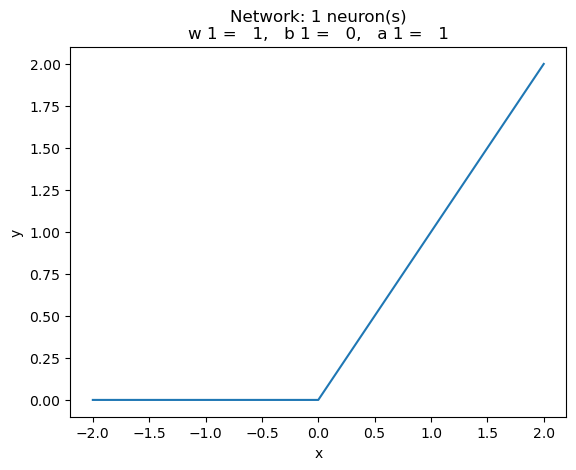

In [5]:
# ReLU function
net = SimpleNet(1)
net.plot(-2, 2)

Flipping the sign of the input weight mirrors the ReLU Horizontally

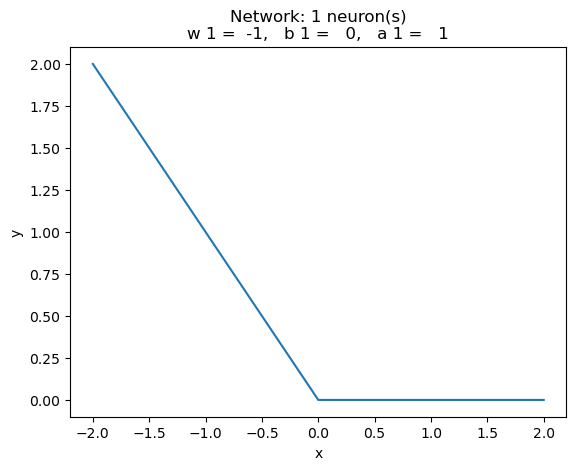

In [6]:
# Mirrored (H) ReLU function
net = SimpleNet(1)
net.update_weights(
    W = [-1],
)
net.plot(-2, 2)

Flipping the sign of the output weight mirrors the ReLU vertically

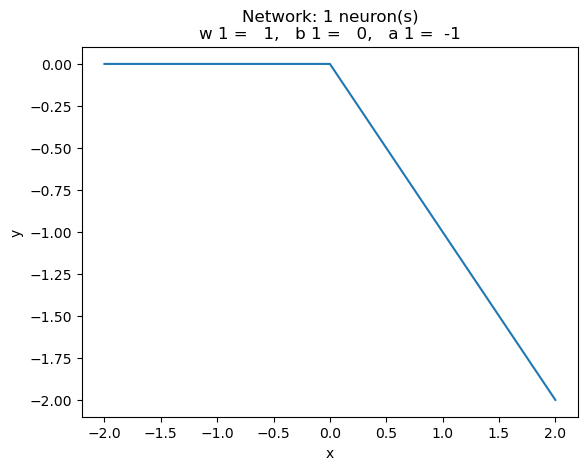

In [7]:
# Mirrored (V) ReLU function
net = SimpleNet(1)
net.update_weights(
    A = [-1],
)
net.plot(-2, 2)

Increasing the bias moves the ReLU to the left

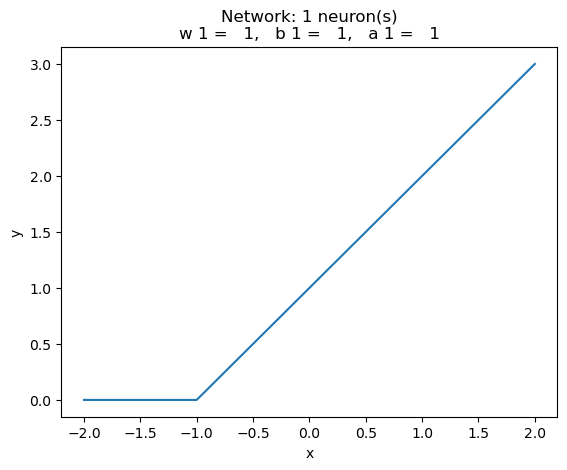

In [8]:
# Shifted ReLU function
net = SimpleNet(1)
net.update_weights(
    B = [1],
)
net.plot(-2, 2)

The shift from the bias is ALSO mirrored (horizontally)

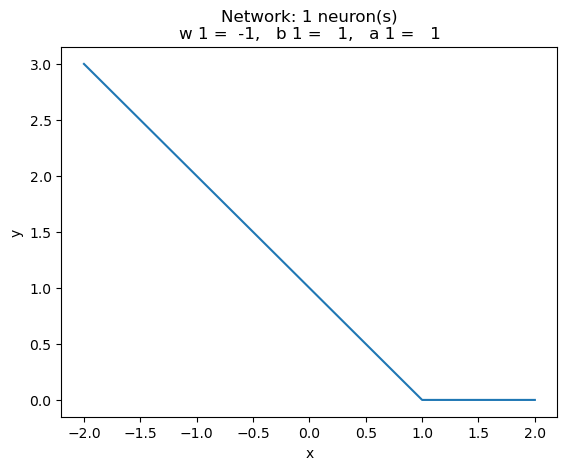

In [9]:
# Shifted mirrored ReLU function
net = SimpleNet(1)
net.update_weights(
    W = [-1],
    B = [1],
)
net.plot(-2, 2)

If you want to mirror only the direction and not the bending point, the sign of both values needs to be flipped

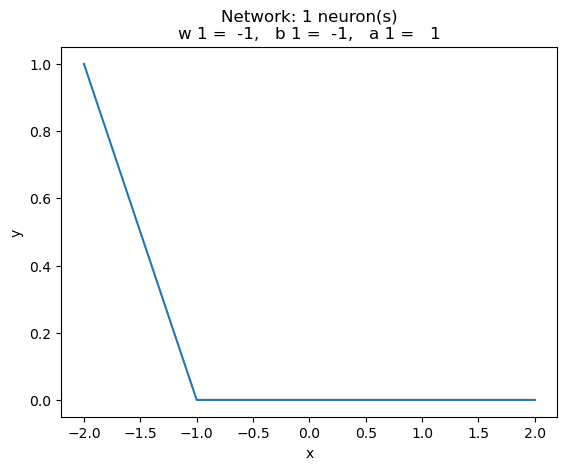

In [10]:
# Shifted mirrored ReLU function
net = SimpleNet(1)
net.update_weights(
    W = [-1],
    B = [-1],
)
net.plot(-2, 2)

If you want to scale the function without moving the bending point, you need to scale the bias too.

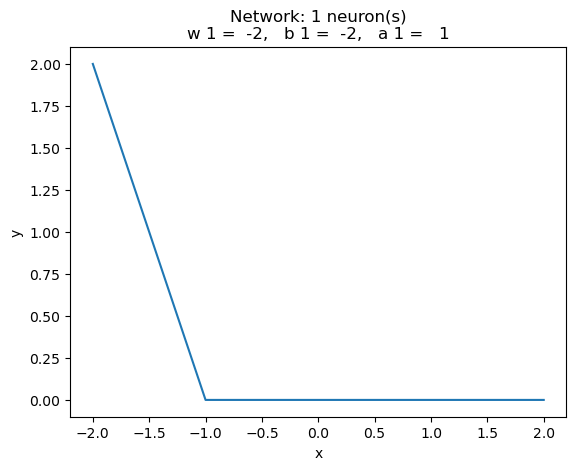

In [21]:
# Shifted mirrored ReLU function
net = SimpleNet(1)
net.update_weights(
    W = [-2],
    B = [-2],
)
net.plot(-2, 2)

## Transformations

I coded some transformations based on these principles.

In [46]:
class Transformations():

    # Flip i-th ReLU horizontally (in place)
    def flip_H(net, i = 1):
        net.W[i - 1] *= -1
        net.B[i - 1] *= -1

    # Flip i-th ReLU vertically (in place)
    def flip_V(net, i = 1):
        net.A[i - 1] *= -1

    # Shift i-th ReLU to the right (by s)
    # (if statement accounts for horizontal mirroring)
    def shift(net, s = 0, i = 1):
        if net.W[i - 1] > 0:
            net.B[i - 1] -= s
        else:
            net.B[i - 1] += s

    # Shift i-th ReLU's bending point to x:
    def shift_to(net, x, i = 1):
        net.B[i - 1] = - x * net.W[i - 1]

    # scale the ReLU by s (in place)
    def scale(net, s = 1, i = 1):
        net.W[i - 1] *= s
        net.B[i - 1] *= s

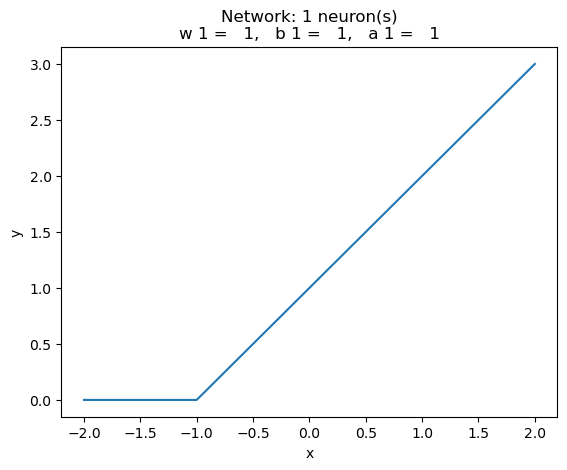

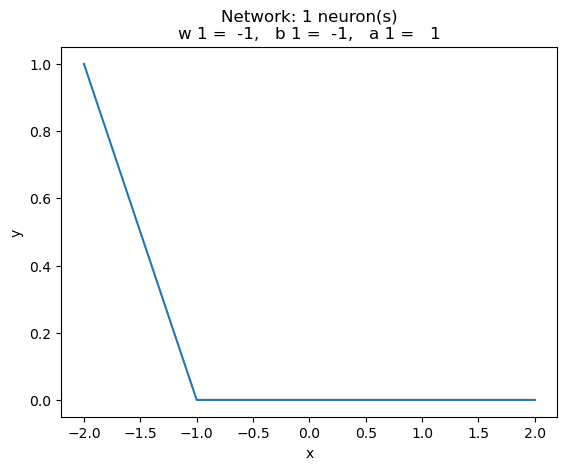

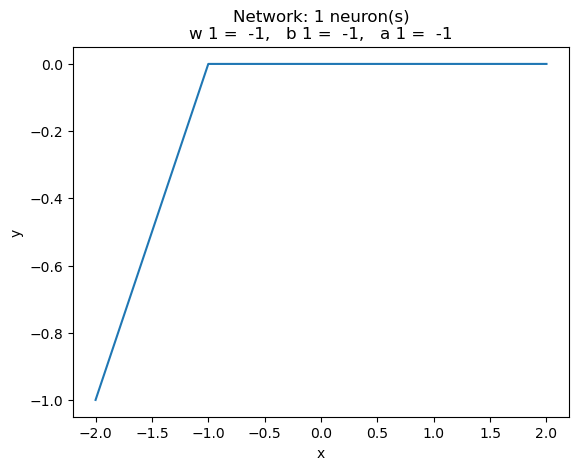

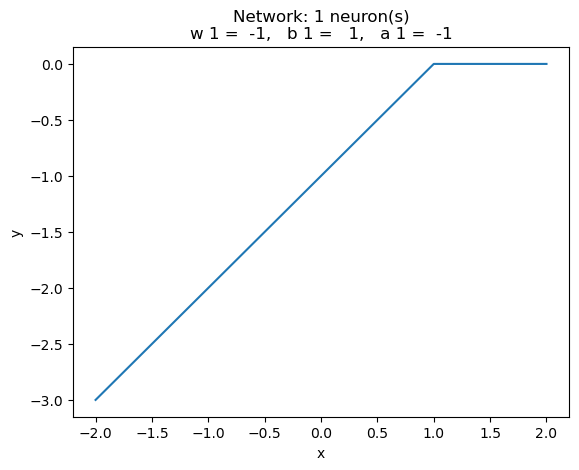

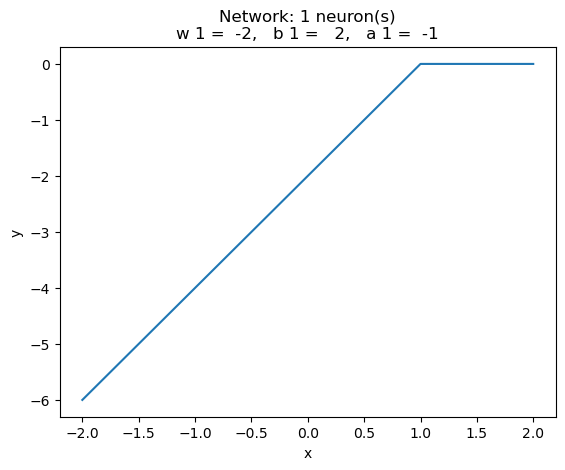

In [27]:
net = SimpleNet(1)

# Shift 1 to the left
Transformations.shift(net, -1)
net.plot(-2, 2)

# Flip horizontally
Transformations.flip_H(net)
net.plot(-2, 2)

# Flip vertically
Transformations.flip_V(net)
net.plot(-2, 2)

# Shift bending point to 1
Transformations.shift_to(net, 1)
net.plot(-2, 2)

# Scale
Transformations.scale(net, 2)
net.plot(-2, 2)

## Multiple ReLU's

I will use these functions to create a double zigzag from -1 to 1 with an amplitude of 2

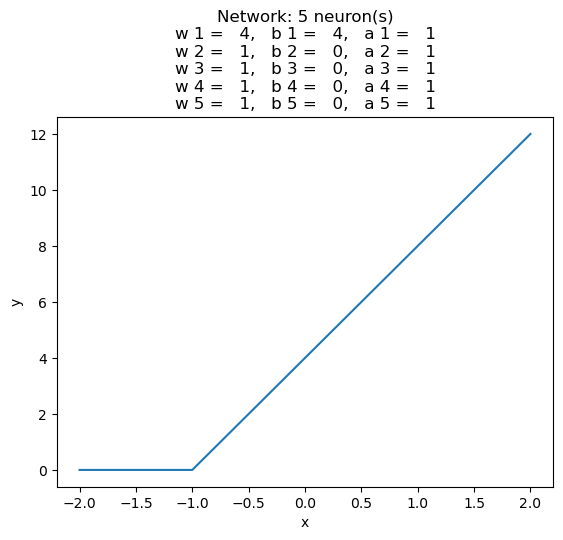

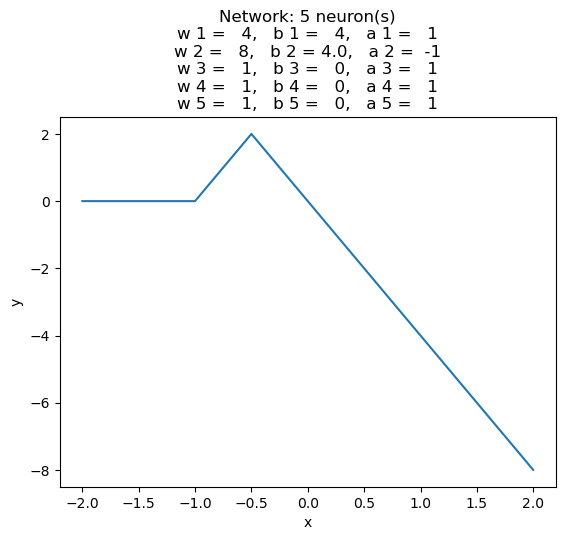

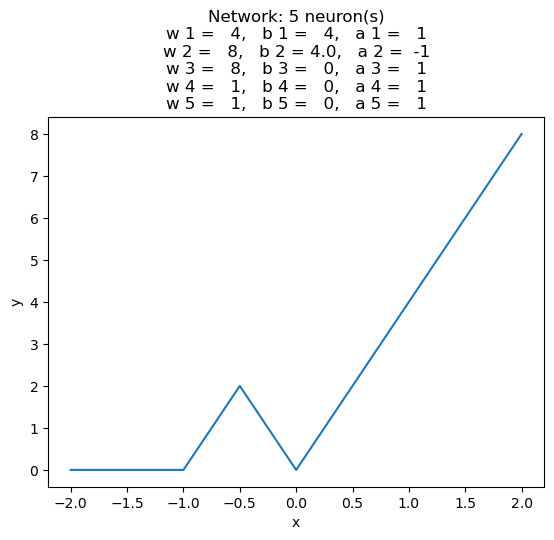

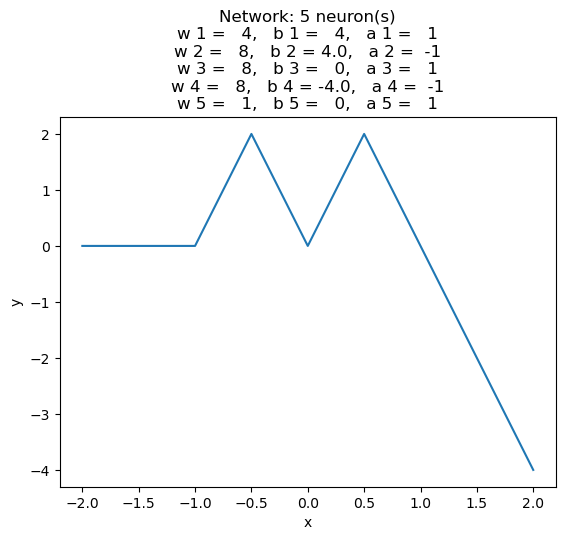

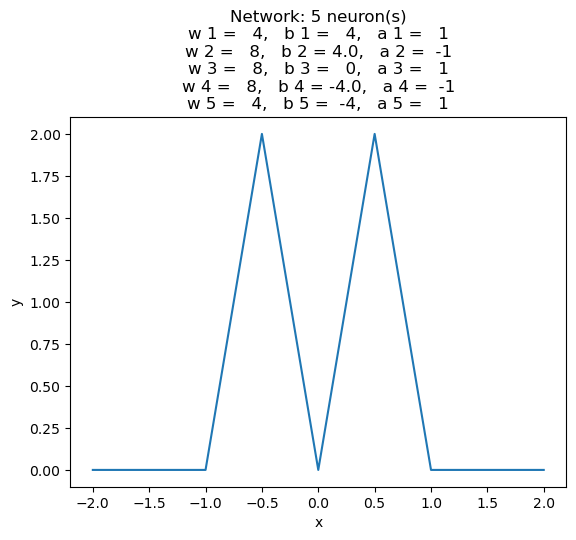

In [39]:
net = SimpleNet(5)

# ReLU 1
Transformations.shift(net, -1, 1)
Transformations.scale(net, 4, 1)
net.plot(-2, 2, 1)

# ReLU 2
Transformations.shift(net, -0.5, 2)
Transformations.flip_V(net, 2)
Transformations.scale(net, 8, 2)
net.plot(-2, 2, 2)

# ReLU 3
Transformations.scale(net, 8, 3)
net.plot(-2, 2, 3)

# ReLU 4
Transformations.shift(net, 0.5, 4)
Transformations.flip_V(net, 4)
Transformations.scale(net, 8, 4)
net.plot(-2, 2, 4)

# ReLU 5
Transformations.shift(net, 1, 5)
Transformations.scale(net, 4, 5)
net.plot(-2, 2, 5)

## Conclusion

An optimal zigzag requires:
- A values that alternate in sign
- W values that 'compensate' for other ReLUs

In theory, an algorithm should be able to find an optimal zigzag by:
- shifting ReLUs
- flipping ReLUs (vertically)
- scaling ReLUs

## Notes

There are multiple possibilities to create optimal zigzags: 
- Scaling can be done both with W and A. 

There are even more possibilities to create suboptimal zigzags:
- ReLU's can be duplicated and stacked
- ReLU's can be duplicated, mirrored and stacked (this creates a V-shape)

## Agglomerate Neurons?

It would be interesting to see whether it's possible to 'agglomerate' neurons, instead of simply creating new ones or removing them. Say you have 2 ReLU's with identical bending points, you could 'merge' them by finding the right weight and bias to represent their combination in a single ReLU. 

Alternatively it would be cool to find a way to collectively flip signs of neurons, a quick example to illustrate:

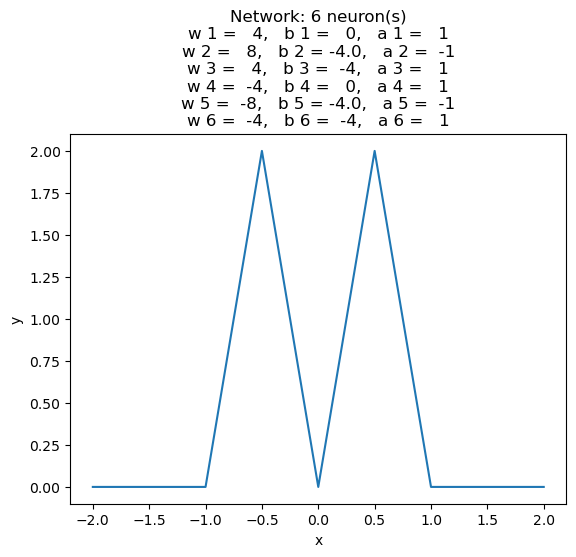

In [61]:
net = SimpleNet(6)

# ReLU 1
Transformations.scale(net, 4, 1)

# ReLU 2
Transformations.shift(net, 0.5, 2)
Transformations.flip_V(net, 2)
Transformations.scale(net, 8, 2)

# ReLU 3
Transformations.shift(net, 1, 3)
Transformations.scale(net, 4, 3)

# ReLU 4
Transformations.flip_H(net, 4)
Transformations.scale(net, 4, 4)

# ReLU 5
Transformations.flip_H(net, 5)
Transformations.shift(net, -0.5, 5)
Transformations.flip_V(net, 5)
Transformations.scale(net, 8, 5)

# ReLU 6
Transformations.flip_H(net, 6)
Transformations.shift(net, -1, 6)
Transformations.scale(net, 4, 6)

net.plot(-2, 2, 6)

This zigzag requires 6 ReLU's because it mirrors the last 3 neurons. It could be fixed by going from

```

      /<    >\                    >\    >\
     /  \  /  \                  /  \  /  \
<---<    \/    >--->   to   --->/    >/    \>---

````

Looking at the weights this would be a possibility:
- find mirroring neurons (1, 2, 3) and (4, 5, 6)
- swap the sign of the mirrored neurons
- find their connection (1 and 4)
- agglomerate the connecting neurons

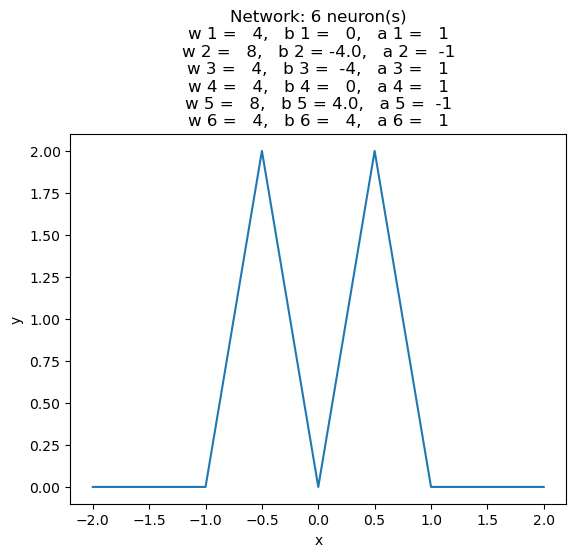

In [62]:
# Flip mirrored neurons
Transformations.flip_H(net, 4)
Transformations.flip_H(net, 5)
Transformations.flip_H(net, 6)

net.plot(-2, 2)

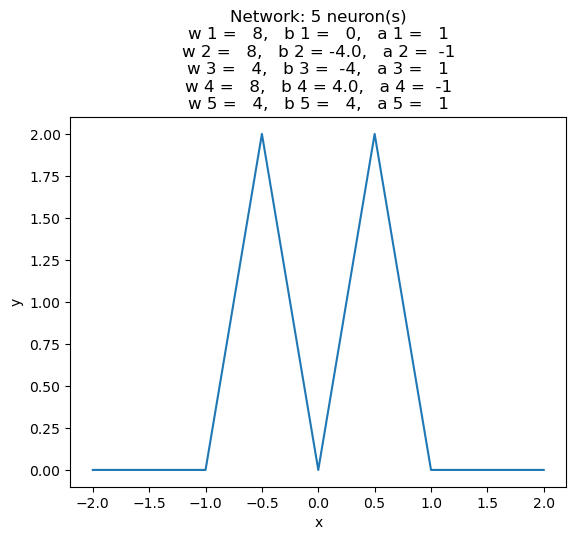

In [63]:
# Remove Neuron 4
W4 = net.W.pop(3)
B4 = net.B.pop(3)
A4 = net.A.pop(3)
net.N -= 1

# Agglomerate neurons
net.W[0] += W4
net.B[0] += B4
net.A[0] *= A4

net.plot(-2, 2)